In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler
import xarray as xr

Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0


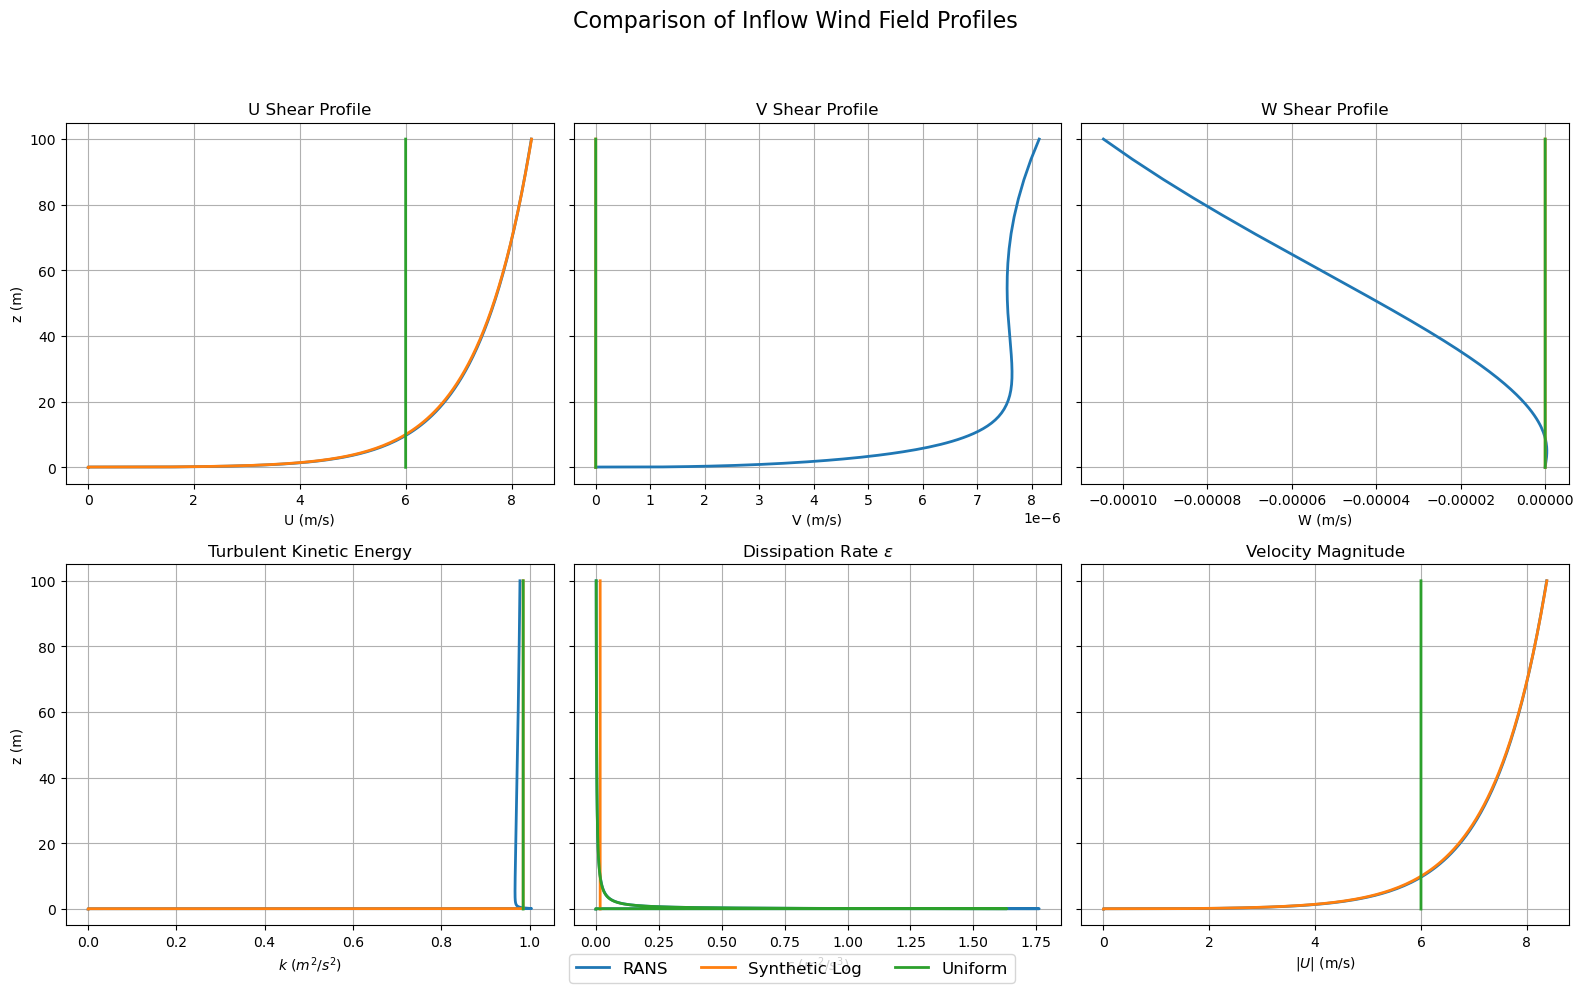

In [12]:
# Rans file and standard conditions
filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
U_ref = 6    # [m/s]
z0 = 0.03   # [m]
wd = 0      # [deg]

# --- Wind field definitions ---
rw = WindField(profile='rans', ds=filepath,U_ref=U_ref)
lw = WindField(profile='log', U_ref=U_ref, z0=z0, direction=wd)
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

point = np.array([100,100]) #x,y coords for the point of interest

point = np.array([100,100]) #x,y coords for the point of interest
z_vals = np.linspace(0.0001, 100, 20000)

urw = np.zeros(len(z_vals))
vrw = np.zeros(len(z_vals))
wrw = np.zeros(len(z_vals))
krw = np.zeros(len(z_vals))
erw = np.zeros(len(z_vals))

ulw = np.zeros(len(z_vals))
vlw = np.zeros(len(z_vals))
wlw = np.zeros(len(z_vals))
klw = np.zeros(len(z_vals))
elw = np.zeros(len(z_vals))

uuw = np.zeros(len(z_vals))
vuw = np.zeros(len(z_vals))
wuw = np.zeros(len(z_vals))
kuw = np.zeros(len(z_vals))
euw = np.zeros(len(z_vals))

for i, z in enumerate(z_vals):

    # --- RANS ---
    vel, krw[i], erw[i] = rw.get_profile_at(x=point[0], y=point[1], z=z)
    urw[i], vrw[i], wrw[i] = vel

    # --- Synthetic Log ---
    vel, klw[i], elw[i] = lw.get_profile_at(x=point[0], y=point[1], z=z)
    ulw[i], vlw[i], wlw[i] = vel

    # --- Uniform ---
    vel, kuw[i], euw[i] = uw.get_profile_at(x=point[0], y=point[1], z=z)
    uuw[i], vuw[i], wuw[i] = vel

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

# ===== First Row =====
# U shear
axs[0,0].plot(urw, z_vals, linewidth=2, label='RANS')
axs[0,0].plot(ulw, z_vals, linewidth=2, label='Synthetic Log')
axs[0,0].plot(uuw, z_vals, linewidth=2, label='Uniform')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_title('U Shear Profile')
axs[0,0].grid(True)

# V shear
axs[0,1].plot(vrw, z_vals, linewidth=2)
axs[0,1].plot(vlw, z_vals, linewidth=2)
axs[0,1].plot(vuw, z_vals, linewidth=2)
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_title('V Shear Profile')

axs[0,1].grid(True)

# W shear
axs[0,2].plot(wrw, z_vals, linewidth=2)
axs[0,2].plot(wlw, z_vals, linewidth=2)
axs[0,2].plot(wuw, z_vals, linewidth=2)
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_title('W Shear Profile')
axs[0,2].grid(True)


# ===== Second Row =====
# TKE

axs[1,0].plot(krw, z_vals, linewidth=2)
axs[1,0].plot(klw, z_vals, linewidth=2)
axs[1,0].plot(kuw, z_vals, linewidth=2)
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')
axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].grid(True)

# epsilon
axs[1,1].plot(elw, z_vals, linewidth=2)
axs[1,1].plot(euw, z_vals, linewidth=2)
axs[1,1].plot(erw, z_vals, linewidth=2)
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')
axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].grid(True)

# Velocity magnitude panel (nice use of 6th slot)
Umag_rw = np.sqrt(urw**2 + vrw**2 + wrw**2)
Umag_lw = np.sqrt(ulw**2 + vlw**2 + wlw**2)
Umag_uw = np.sqrt(uuw**2 + vuw**2 + wuw**2)

axs[1,2].plot(Umag_rw, z_vals, linewidth=2)
axs[1,2].plot(Umag_lw, z_vals, linewidth=2)
axs[1,2].plot(Umag_uw, z_vals, linewidth=2)
axs[1,2].set_xlabel(r'$|U|$ (m/s)')
axs[1,2].set_title('Velocity Magnitude')
axs[1,2].grid(True)

# Global legend
fig.legend(['RANS', 'Synthetic Log', 'Uniform'],
           loc='lower center',
           ncol=3,
           fontsize=12,
           frameon=True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.94])
plt.show()

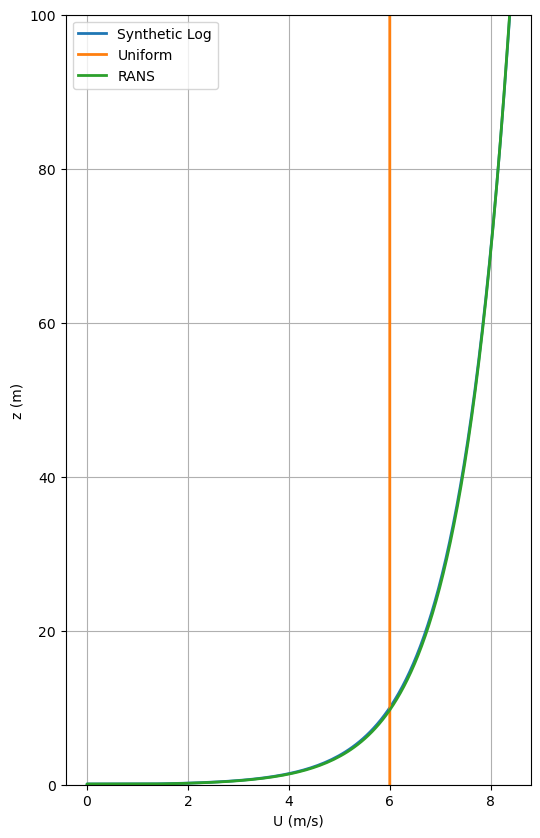

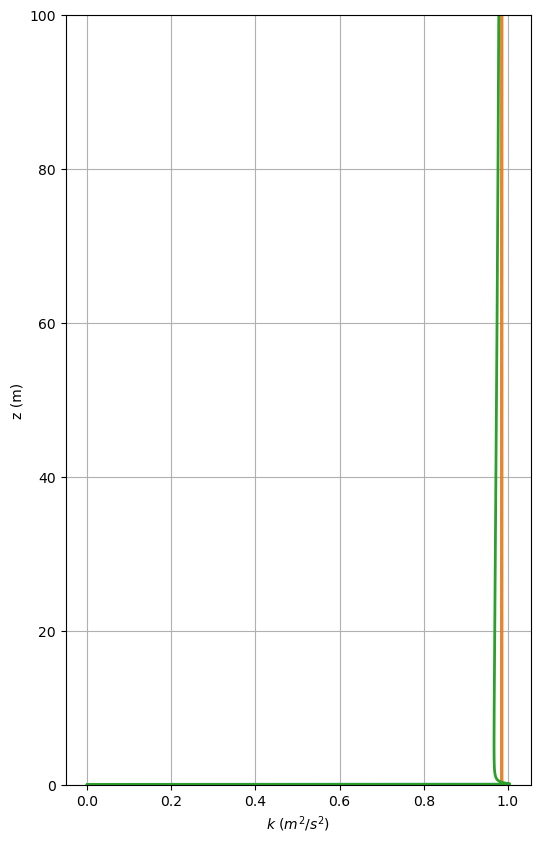

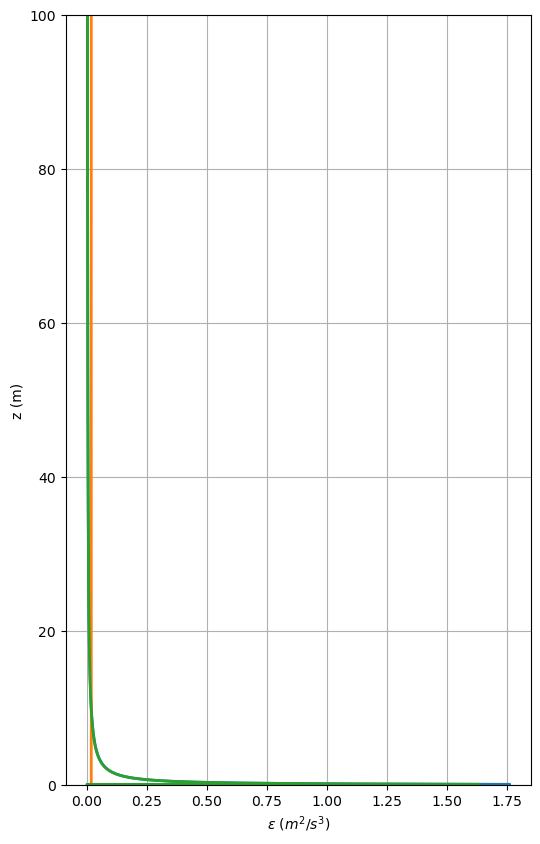

In [13]:
plt.figure(figsize=(6,10))
plt.plot(ulw, z_vals, linewidth=2, label='Synthetic Log')
plt.plot(uuw, z_vals, linewidth=2, label='Uniform')
plt.plot(urw, z_vals, linewidth=2, label='RANS')
plt.xlabel('U (m/s)')
plt.ylabel('z (m)')
plt.legend()
plt.ylim(0,100)
plt.grid()
plt.show()

plt.figure(figsize=(6,10))
plt.plot(klw, z_vals, linewidth=2, label='Synthetic Log')
plt.plot(kuw, z_vals, linewidth=2, label='Uniform')
plt.plot(krw, z_vals, linewidth=2, label='RANS')
plt.ylim(0,100)
plt.xlabel(r'$k$ ($m^2/s^2$)')
plt.ylabel('z (m)')
plt.grid()
plt.show()

plt.figure(figsize=(6,10))
plt.plot(elw, z_vals, linewidth=2, label='Synthetic Log')
plt.plot(euw, z_vals, linewidth=2, label='Uniform')
plt.plot(erw, z_vals, linewidth=2, label='RANS')
plt.xlabel(r'$\varepsilon$ ($m^2/s^3$)')
plt.ylabel('z (m)')
plt.ylim(0,100)
plt.grid()
plt.show()


In [22]:
## Plot showing u wind components for uniform, and different z0 values
# filepaths for RANS simulations with varying z0
datafile01 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.001_mb_cartesian.nc'
datafile02 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0021_mb_cartesian.nc'
datafile03 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0046_mb_cartesian.nc'
datafile04 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.01_mb_cartesian.nc'
datafile05 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
datafile06 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.046_mb_cartesian.nc'
datafile07 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.1_mb_cartesian.nc'
datafile08 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.21_mb_cartesian.nc'
datafile09 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.46_mb_cartesian.nc'
datafile10 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_1_mb_cartesian.nc'

z0_file_library = {
    0.001:                  datafile01,
    0.0021544:              datafile02,
    0.0046415:              datafile03,
    0.01:                   datafile04,
    0.03:                   datafile05, # baseline
    0.046415:               datafile06, 
    0.1:                    datafile07,
    0.215443:               datafile08,
    0.464158:               datafile09,
    1.0:                    datafile10
}

wf01 = WindField(profile='rans', ds=datafile01, U_ref=U_ref)
wf02 = WindField(profile='rans', ds=datafile02, U_ref=U_ref)
wf03 = WindField(profile='rans', ds=datafile03, U_ref=U_ref)
wf04 = WindField(profile='rans', ds=datafile04, U_ref=U_ref)
wf05 = WindField(profile='rans', ds=datafile05, U_ref=U_ref)
wf06 = WindField(profile='rans', ds=datafile06, U_ref=U_ref)
wf07 = WindField(profile='rans', ds=datafile07, U_ref=U_ref)
wf08 = WindField(profile='rans', ds=datafile08, U_ref=U_ref)
wf09 = WindField(profile='rans', ds=datafile09, U_ref=U_ref)
wf10 = WindField(profile='rans', ds=datafile10, U_ref=U_ref)

U_ref = 6    # [m/s]
wd = 0      # [deg]

uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

wf_library = {
    0.001:                  wf01,
    0.0021544:              wf02,
    0.0046415:              wf03,
    0.01:                   wf04,
    0.03:                   wf05,
    0.046415:               wf06, # baseline
    0.1:                    wf07,
    0.215443:               wf08,
    0.464158:               wf09,
    1.0:                    wf10
}

Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0


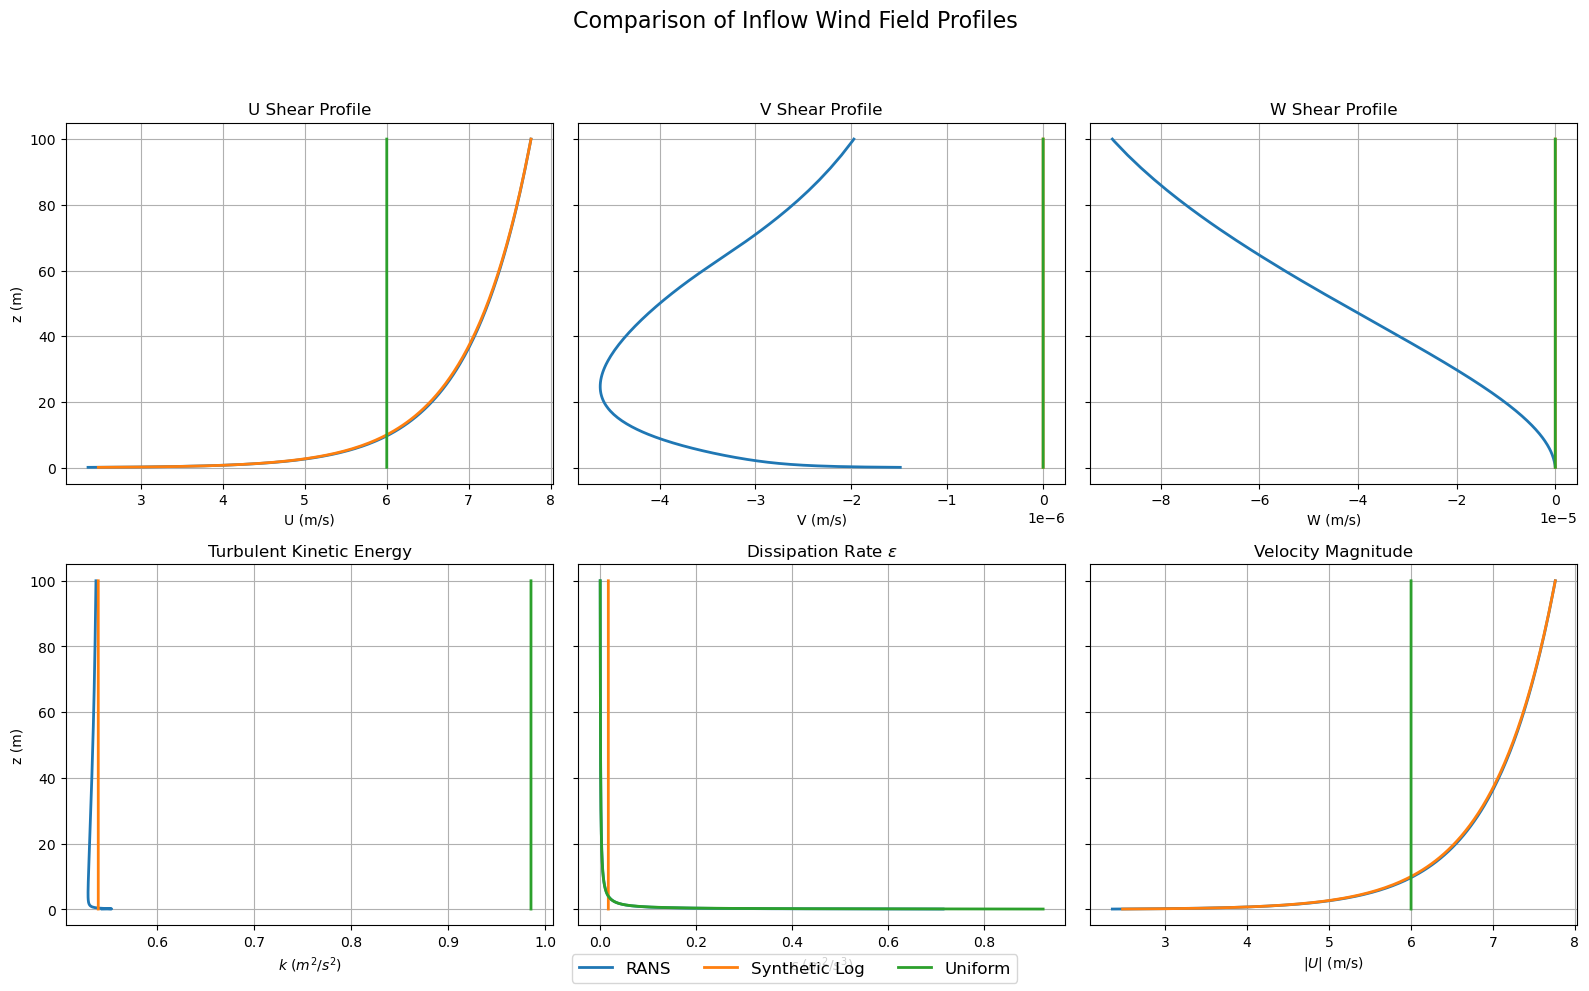

In [23]:
point = np.array([10,10]) #x,y coords for the point of interest
z_vals = np.linspace(0.1, 100, 2000)

urw = np.zeros(len(z_vals))
vrw = np.zeros(len(z_vals))
wrw = np.zeros(len(z_vals))
krw = np.zeros(len(z_vals))
erw = np.zeros(len(z_vals))

ulw = np.zeros(len(z_vals))
vlw = np.zeros(len(z_vals))
wlw = np.zeros(len(z_vals))
klw = np.zeros(len(z_vals))
elw = np.zeros(len(z_vals))

uuw = np.zeros(len(z_vals))
vuw = np.zeros(len(z_vals))
wuw = np.zeros(len(z_vals))
kuw = np.zeros(len(z_vals))
euw = np.zeros(len(z_vals))

for i, z in enumerate(z_vals):

    # --- RANS ---
    vel, krw[i], erw[i] = rw.get_profile_at(x=point[0], y=point[1], z=z)
    urw[i], vrw[i], wrw[i] = vel

    # --- Synthetic Log ---
    vel, klw[i], elw[i] = lw.get_profile_at(x=point[0], y=point[1], z=z)
    ulw[i], vlw[i], wlw[i] = vel

    # --- Uniform ---
    vel, kuw[i], euw[i] = uw.get_profile_at(x=point[0], y=point[1], z=z)
    uuw[i], vuw[i], wuw[i] = vel

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

# ===== First Row =====
# U shear
axs[0,0].plot(urw, z_vals, linewidth=2, label='RANS')
axs[0,0].plot(ulw, z_vals, linewidth=2, label='Synthetic Log')
axs[0,0].plot(uuw, z_vals, linewidth=2, label='Uniform')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_title('U Shear Profile')

axs[0,0].grid(True)

# V shear
axs[0,1].plot(vrw, z_vals, linewidth=2)
axs[0,1].plot(vlw, z_vals, linewidth=2)
axs[0,1].plot(vuw, z_vals, linewidth=2)
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_title('V Shear Profile')

axs[0,1].grid(True)

# W shear
axs[0,2].plot(wrw, z_vals, linewidth=2)
axs[0,2].plot(wlw, z_vals, linewidth=2)
axs[0,2].plot(wuw, z_vals, linewidth=2)
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_title('W Shear Profile')
axs[0,2].grid(True)


# ===== Second Row =====
# TKE

axs[1,0].plot(krw, z_vals, linewidth=2)
axs[1,0].plot(klw, z_vals, linewidth=2)
axs[1,0].plot(kuw, z_vals, linewidth=2)
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')
axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].grid(True)

# epsilon
axs[1,1].plot(elw, z_vals, linewidth=2)
axs[1,1].plot(euw, z_vals, linewidth=2)
axs[1,1].plot(erw, z_vals, linewidth=2)
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')
axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].grid(True)

# Velocity magnitude panel (nice use of 6th slot)
Umag_rw = np.sqrt(urw**2 + vrw**2 + wrw**2)
Umag_lw = np.sqrt(ulw**2 + vlw**2 + wlw**2)
Umag_uw = np.sqrt(uuw**2 + vuw**2 + wuw**2)

axs[1,2].plot(Umag_rw, z_vals, linewidth=2)
axs[1,2].plot(Umag_lw, z_vals, linewidth=2)
axs[1,2].plot(Umag_uw, z_vals, linewidth=2)
axs[1,2].set_xlabel(r'$|U|$ (m/s)')
axs[1,2].set_title('Velocity Magnitude')
axs[1,2].grid(True)

# Global legend
fig.legend(['RANS', 'Synthetic Log', 'Uniform'],
           loc='lower center',
           ncol=3,
           fontsize=12,
           frameon=True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.94])
plt.show()

In [24]:
rw.ds.U

<xarray.DataArray 'U' (x: 128, y: 128, z: 160)> Size: 10MB
array([[[1.985364 , 2.7599673, 3.1745443, ..., 8.903167 , 8.939262 ,
         8.974    ],
        [1.985364 , 2.7599673, 3.1745443, ..., 8.903167 , 8.939262 ,
         8.974    ],
        [1.985364 , 2.7599673, 3.1745443, ..., 8.903167 , 8.939262 ,
         8.974    ],
        ...,
        [1.985364 , 2.7599673, 3.1745443, ..., 8.903167 , 8.939262 ,
         8.974    ],
        [1.985364 , 2.7599673, 3.1745443, ..., 8.903167 , 8.939262 ,
         8.974    ],
        [1.985364 , 2.7599673, 3.1745443, ..., 8.903167 , 8.939262 ,
         8.974    ]],

       [[1.9829147, 2.7564514, 3.1710358, ..., 8.903043 , 8.939189 ,
         8.973979 ],
        [1.9829147, 2.7564514, 3.1710358, ..., 8.903043 , 8.939189 ,
         8.973979 ],
        [1.9829147, 2.7564514, 3.1710358, ..., 8.903043 , 8.939189 ,
         8.973979 ],
...
        [1.984966 , 2.7594373, 3.1745849, ..., 8.901507 , 8.938255 ,
         8.973665 ],
        [1.9849663, 2.7594376, 3.1745849, ..., 8.901507 , 8.938255 ,
         8.973665 ],
        [1.9849663, 2.7594376, 3.1745849, ..., 8.901507 , 8.938255 ,
         8.973665 ]],

       [[1.9849724, 2.759446 , 3.1745946, ..., 8.901477 , 8.938237 ,
         8.973661 ],
        [1.9849725, 2.7594461, 3.1745949, ..., 8.901477 , 8.938237 ,
         8.973661 ],
        [1.9849727, 2.7594464, 3.1745949, ..., 8.901477 , 8.938237 ,
         8.973661 ],
        ...,
        [1.9849709, 2.7594438, 3.174592 , ..., 8.901477 , 8.938237 ,
         8.973661 ],
        [1.9849709, 2.759444 , 3.1745925, ..., 8.901477 , 8.938237 ,
         8.973661 ],
        [1.984971 , 2.7594442, 3.1745925, ..., 8.901477 , 8.938237 ,
         8.973661 ]]], dtype=float32)
Coordinates:
  * x        (x) float32 512B -5.114e+03 -4.745e+03 ... 4.745e+03 5.114e+03
  * y        (y) float32 512B -5.114e+03 -4.745e+03 ... 4.745e+03 5.114e+03
  * z        (z) float32 640B 0.05077 0.1539 0.2602 0.3698 ... 445.9 467.4 489.1
Attributes:
    long_name:  streamwise wind component
    units:      m/s

In [25]:
lw.ds.U

<xarray.DataArray 'U' (z: 100)> Size: 800B
array([2.47983942, 2.53317518, 2.58651095, 2.63984672, 2.69318248,
       2.74651825, 2.79985402, 2.85318978, 2.90652555, 2.95986131,
       3.01319708, 3.06653285, 3.11986861, 3.17320438, 3.22654015,
       3.27987591, 3.33321168, 3.38654745, 3.43988321, 3.49321898,
       3.54655475, 3.59989051, 3.65322628, 3.70656204, 3.75989781,
       3.81323358, 3.86656934, 3.91990511, 3.97324088, 4.02657664,
       4.07991241, 4.13324818, 4.18658394, 4.23991971, 4.29325547,
       4.34659124, 4.39992701, 4.45326277, 4.50659854, 4.55993431,
       4.61327007, 4.66660584, 4.71994161, 4.77327737, 4.82661314,
       4.87994891, 4.93328467, 4.98662044, 5.0399562 , 5.09329197,
       5.14662774, 5.1999635 , 5.25329927, 5.30663504, 5.3599708 ,
       5.41330657, 5.46664234, 5.5199781 , 5.57331387, 5.62664964,
       5.6799854 , 5.73332117, 5.78665693, 5.8399927 , 5.89332847,
       5.94666423, 6.        , 6.05333577, 6.10667153, 6.1600073 ,
       6.21334307, 6.26667883, 6.3200146 , 6.37335036, 6.42668613,
       6.4800219 , 6.53335766, 6.58669343, 6.6400292 , 6.69336496,
       6.74670073, 6.8000365 , 6.85337226, 6.90670803, 6.9600438 ,
       7.01337956, 7.06671533, 7.12005109, 7.17338686, 7.22672263,
       7.28005839, 7.33339416, 7.38672993, 7.44006569, 7.49340146,
       7.54673723, 7.60007299, 7.65340876, 7.70674453, 7.76008029])
Coordinates:
  * z        (z) float64 800B 0.1 0.1072 0.115 0.1233 ... 86.97 93.26 100.0